## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

warnings.filterwarnings("ignore")
np.random.seed(42)


@dataclass(frozen=True)
class Config:
    panel_path: str = "djia_panel_finale_v2.csv"
    index_path: str = "djia_index_series_v2.csv"
    min_train_months: int = 24      # warm-up: primo rebalance 2009-04
    rebalance_months: List[int] = (4, 10)  # EOM aprile / ottobre
    w_min: float = 0.01
    w_max: float = 0.15


CFG = Config()

panel = (pd.read_csv(CFG.panel_path, parse_dates=["Date"])
         .sort_values(["Date", "Ticker"]).reset_index(drop=True))
index_series = (pd.read_csv(CFG.index_path, parse_dates=["Date"])
                .sort_values("Date").reset_index(drop=True))

print(f"Panel  : {panel.shape}  |  {panel.Date.min().date()} → {panel.Date.max().date()}")
print(f"Ticker : {panel.Ticker.nunique()} unici  |  Mesi: {panel.Date.nunique()}")

Panel  : (6960, 34)  |  2007-01-31 → 2026-04-30
Ticker : 49 unici  |  Mesi: 232


## 2. Ricostruzione del DJIATR vs benchmark ufficiale

### 2.1 Metodologia della ricostruzione

Il DJIA ufficiale è un indice **price-weighted** con divisore aggiornato a
ogni split e a ogni rotazione di componenti: `Index_t = Σ P_i,t / D_t`. La
versione Total Return (DJITR) reinvestisce i dividendi.

Il builder `djia_02_reconstruction.ipynb` produce due serie price-weighted:

| Serie | Costruzione | TE vs DJITR | CAGR bias | Uso nel notebook |
|---|---|---|---|---|
| `Return_PW` | Σ(Weight_PW × Return_monthly) | **1.97%** | +4.38 pp/y | diagnostica TE |
| `Index_PW_v3` | Chain-linking con divisore aggiornato | 2.79% | −0.61 pp/y | plot livelli |

**Benchmark adottato.** In questo notebook tutte le metriche strategia vs
benchmark sono calcolate vs **DJITR ufficiale** (`Return_DJITR`). La nostra
ricostruzione è mostrata come validazione: vogliamo verificare che il panel
di dati dei 30 componenti catturi fedelmente l'indice ufficiale, così
qualsiasi divergenza strategia vs DJITR è **vero alpha**, non un artefatto
del dataset.

In [2]:
def reconstruction_metrics(recon_return: pd.Series,
                           djitr_return: pd.Series) -> pd.Series:
    common = recon_return.index.intersection(djitr_return.index)
    rp, rd = recon_return.loc[common], djitr_return.loc[common]

    def ann(r):
        mu = (1 + r).prod() ** (12 / len(r)) - 1
        vol = r.std() * np.sqrt(12)
        return mu, vol

    mu_r, vol_r = ann(rd)
    mu_x, vol_x = ann(rp)
    beta = np.cov(rp, rd, ddof=0)[0, 1] / np.var(rd, ddof=0)
    return pd.Series({
        "months": len(common),
        "correlation": rp.corr(rd),
        "tracking_error_ann_%": (rp - rd).std() * np.sqrt(12) * 100,
        "beta_vs_djitr": beta,
        "cagr_djitr_%": mu_r * 100,
        "cagr_recon_%": mu_x * 100,
        "cagr_diff_pp": (mu_x - mu_r) * 100,
        "vol_djitr_%": vol_r * 100,
        "vol_recon_%": vol_x * 100,
    }).round(4)

djitr_level = index_series.set_index("Date")["DJITR_Close"].dropna().rename("DJITR")
djitr_return = index_series.set_index("Date")["Return_DJITR"].dropna().rename("DJITR_Return")
recon_level  = index_series.set_index("Date")["Index_PW_v3"].dropna().rename("Recon_Level")

# Ricalcolo recon_return da recon_level per garantire coerenza con i livelli
recon_return = (recon_level.pct_change()).dropna().rename("Recon_Return")

print(f"DJITR ufficiale : {djitr_return.index.min().date()} → "
      f"{djitr_return.index.max().date()}  |  {len(djitr_return)} mesi")
print(f"Ricostruzione ricalcolata: {recon_return.index.min().date()} → "
      f"{recon_return.index.max().date()}  |  {len(recon_return)} mesi")

# Adding a print to display the metrics immediately after recon_return is updated.
metrics = reconstruction_metrics(recon_return, djitr_return)
print(f"\nMetrics for Reconstruction based on Index_PW_v3 (vs DJITR) after recalculation:\n")
print(f"  CAGR (Index_PW_v3): {metrics['cagr_recon_%']:.2f}%")
print(f"  Tracking Error (Index_PW_v3): {metrics['tracking_error_ann_%']:.2f}%")
print(f"  DJITR CAGR (for comparison): {metrics['cagr_djitr_%']:.2f}%")

DJITR ufficiale : 2007-04-30 → 2026-04-30  |  229 mesi
Ricostruzione ricalcolata: 2007-02-28 → 2026-04-30  |  231 mesi

Metrics for Reconstruction based on Index_PW_v3 (vs DJITR) after recalculation:

  CAGR (Index_PW_v3): 9.04%
  Tracking Error (Index_PW_v3): 3.09%
  DJITR CAGR (for comparison): 10.12%


In [3]:
# Derivazione di recon_return_pw e recon_level_pw dalla colonna 'Return_PW'
recon_return_pw = index_series.set_index("Date")["Return_PW"].dropna().rename("Recon_Return_PW")

# Per la comparazione dei livelli, creiamo una serie di livelli partendo da 100 alla prima data utile di Return_PW
first_valid_date_pw_return = recon_return_pw.index.min()
# Assicurati che l'inizio del livello sia allineato con la prima data di Return_PW
initial_level_pw = 100.0 / (1 + recon_return_pw.iloc[0]) # Adjust initial_level so that (1+first_return) * initial_level = 100
recon_level_pw = (1 + recon_return_pw).cumprod() * initial_level_pw

# Rinomina la serie per chiarezza nel plot
recon_level_pw.name = "Recon_Level_PW_from_Return_PW"

print(f"Ricostruzione Return_PW: {recon_return_pw.index.min().date()} → "
      f"{recon_return_pw.index.max().date()}  |  {len(recon_return_pw)} mesi")

Ricostruzione Return_PW: 2007-02-28 → 2026-04-30  |  231 mesi


### 2.2 Confronto livelli: assoluto (doppio asse Y) e normalizzato

Due plot affiancati per mostrare sia le scale native (indice DJITR ufficiale
vs nostra ricostruzione chain-linked partita da 100) sia la normalizzazione
base 100 per la comparazione visiva di slope.

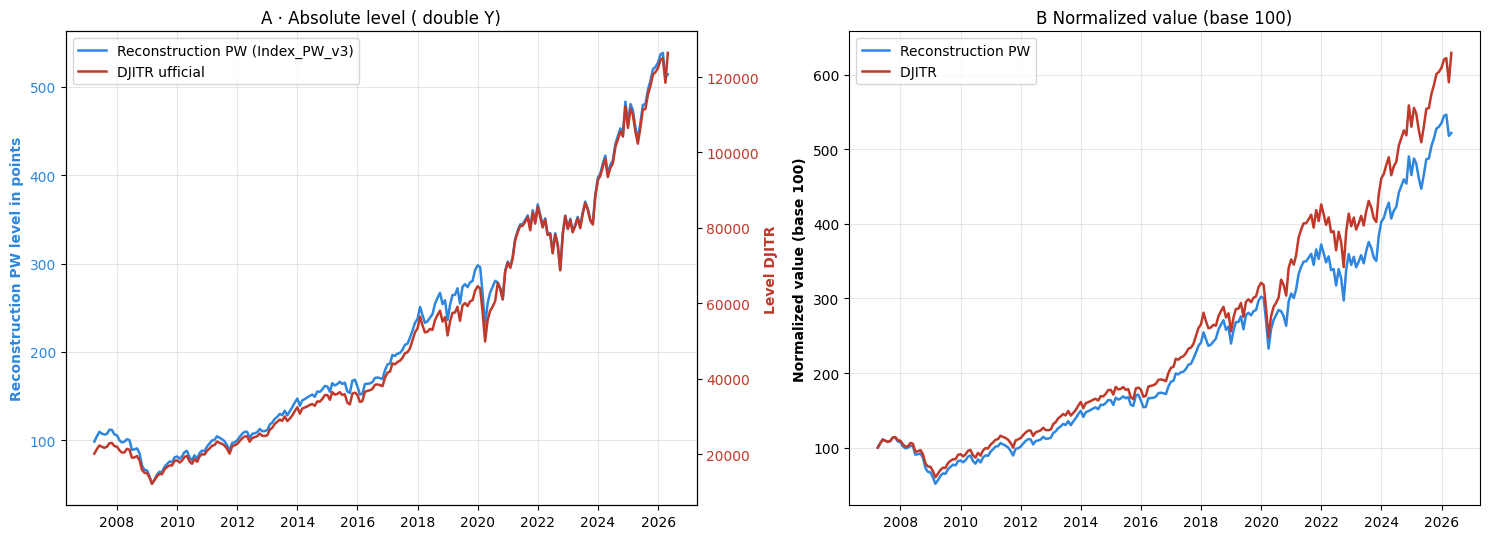

Ret cumulativo ricostruzione : +421.68%
Ret cumulativo DJITR         : +529.01%
Scostamento finale relativo  :  -17.06%


In [4]:
def plot_level_comparison(djitr_level: pd.Series, recon_level: pd.Series):
    first = max(djitr_level.first_valid_index(), recon_level.first_valid_index())
    dj = djitr_level.loc[first:]
    rc = recon_level.loc[first:]
    dj_n = dj / dj.iloc[0] * 100
    rc_n = rc / rc.iloc[0] * 100

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    # Panel A: livelli assoluti, doppio asse Y
    ax = axes[0]
    l1, = ax.plot(rc.index, rc, color="#2e86de", lw=1.8, label="Reconstruction PW (Index_PW_v3)")
    ax.set_ylabel("Reconstruction PW level in points", color="#2e86de", fontweight="bold")
    ax.tick_params(axis="y", labelcolor="#2e86de")
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    l2, = ax2.plot(dj.index, dj, color="#c0392b", lw=1.8, label="DJITR ufficial")
    ax2.set_ylabel("Level DJITR", color="#c0392b", fontweight="bold")
    ax2.tick_params(axis="y", labelcolor="#c0392b")
    ax.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="upper left")
    ax.set_title("A · Absolute level ( double Y)")

    # Panel B: base 100
    ax = axes[1]
    ax.plot(rc_n.index, rc_n, color="#2e86de", lw=1.8, label="Reconstruction PW")
    ax.plot(dj_n.index, dj_n, color="#c0392b", lw=1.8, label="DJITR ")
    ax.set_ylabel("Normalized value (base 100)", fontweight="bold")
    ax.set_title("B Normalized value (base 100)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    gap = (rc_n.iloc[-1] - dj_n.iloc[-1]) / dj_n.iloc[-1] * 100
    print(f"Ret cumulativo ricostruzione : {(rc_n.iloc[-1]/100-1)*100:+7.2f}%")
    print(f"Ret cumulativo DJITR         : {(dj_n.iloc[-1]/100-1)*100:+7.2f}%")
    print(f"Scostamento finale relativo  : {gap:+7.2f}%")


plot_level_comparison(djitr_level, recon_level)

### 2.3 Quality metrics della ricostruzione

In [5]:
def reconstruction_metrics(recon_return: pd.Series,
                           djitr_return: pd.Series) -> pd.Series:
    common = recon_return.index.intersection(djitr_return.index)
    rp, rd = recon_return.loc[common], djitr_return.loc[common]

    def ann(r):
        mu = (1 + r).prod() ** (12 / len(r)) - 1
        vol = r.std() * np.sqrt(12)
        return mu, vol

    mu_r, vol_r = ann(rd)
    mu_x, vol_x = ann(rp)
    beta = np.cov(rp, rd, ddof=0)[0, 1] / np.var(rd, ddof=0)
    return pd.Series({
        "months": len(common),
        "correlation": rp.corr(rd),
        "tracking_error_ann_%": (rp - rd).std() * np.sqrt(12) * 100,
        "beta_vs_djitr": beta,
        "cagr_djitr_%": mu_r * 100,
        "cagr_recon_%": mu_x * 100,
        "cagr_diff_pp": (mu_x - mu_r) * 100,
        "vol_djitr_%": vol_r * 100,
        "vol_recon_%": vol_x * 100,
    }).round(4)


metrics = reconstruction_metrics(recon_return, djitr_return)
print(f"CAGR DJITR: {metrics['cagr_djitr_%']:.2f}%")
print(f"CAGR Reconstruction (ricalcolato): {metrics['cagr_recon_%']:.2f}%")

CAGR DJITR: 10.12%
CAGR Reconstruction (ricalcolato): 9.04%


In [6]:
# Calcolo e visualizzazione delle metriche per Return_PW
metrics_return_pw = reconstruction_metrics(recon_return_pw, djitr_return)

print(f"\nAnnual Performance Metrics for Return_PW (vs DJITR):\n")
print(f"  CAGR (Return_PW): {metrics_return_pw['cagr_recon_%']:.2f}%")
print(f"  Tracking Error (Return_PW): {metrics_return_pw['tracking_error_ann_%']:.2f}%")
print(f"  DJITR CAGR (for comparison): {metrics_return_pw['cagr_djitr_%']:.2f}%")


Annual Performance Metrics for Return_PW (vs DJITR):

  CAGR (Return_PW): 13.98%
  Tracking Error (Return_PW): 2.42%
  DJITR CAGR (for comparison): 10.12%


In [7]:
BACKTEST_START = pd.Timestamp('2009-04-01')
BACKTEST_END = pd.Timestamp('2026-03-31')

recon_return_pw_bt = recon_return_pw.loc[BACKTEST_START:BACKTEST_END].dropna()
print(f"\nOrizzonte Return_PW per benchmark diagnostics: {recon_return_pw_bt.index.min().date()} → "
      f"{recon_return_pw_bt.index.max().date()}  |  {len(recon_return_pw_bt)} mesi")
# Assuming benchmark_diagnostics is defined elsewhere or will be defined later
# benchmark_diagnostics(recon_return_pw_bt, title_prefix="Return_PW (2009-04 → 2026-03)")


Orizzonte Return_PW per benchmark diagnostics: 2009-04-30 → 2026-03-31  |  204 mesi


In [8]:
# Confronto di `Index_PW_v3` vs DJITR per il periodo di training del modello
START_TRAIN_DATE = pd.Timestamp("2010-12-31")
IS_END           = pd.Timestamp("2018-12-31")

recon_return_train = recon_return.loc[START_TRAIN_DATE:IS_END]
djitr_return_train = djitr_return.loc[START_TRAIN_DATE:IS_END]

if not recon_return_train.empty and not djitr_return_train.empty:
    metrics_train_period = reconstruction_metrics(recon_return_train, djitr_return_train)
    print(f"\nAnnual Performance Metrics for Index_PW_v3 vs DJITR (periodo training: {START_TRAIN_DATE.date()} → {IS_END.date()}):\n")
    print(f"  CAGR (Index_PW_v3): {metrics_train_period['cagr_recon_%']:.2f}%")
    print(f"  Tracking Error (Index_PW_v3): {metrics_train_period['tracking_error_ann_%']:.2f}%")
    print(f"  DJITR CAGR (for comparison): {metrics_train_period['cagr_djitr_%']:.2f}%")
else:
    print("Dati insufficienti per il calcolo del Tracking Error nel periodo di training specificato.")


Annual Performance Metrics for Index_PW_v3 vs DJITR (periodo training: 2010-12-31 → 2018-12-31):

  CAGR (Index_PW_v3): 13.03%
  Tracking Error (Index_PW_v3): 1.83%
  DJITR CAGR (for comparison): 12.50%


# Training set comparisong for ML models of the other notebooks!!


Comparazione dei livelli: DJITR ufficiale vs ricostruzione `Index_PW_v3` per il periodo di training (2010-12-31 → 2018-12-31)


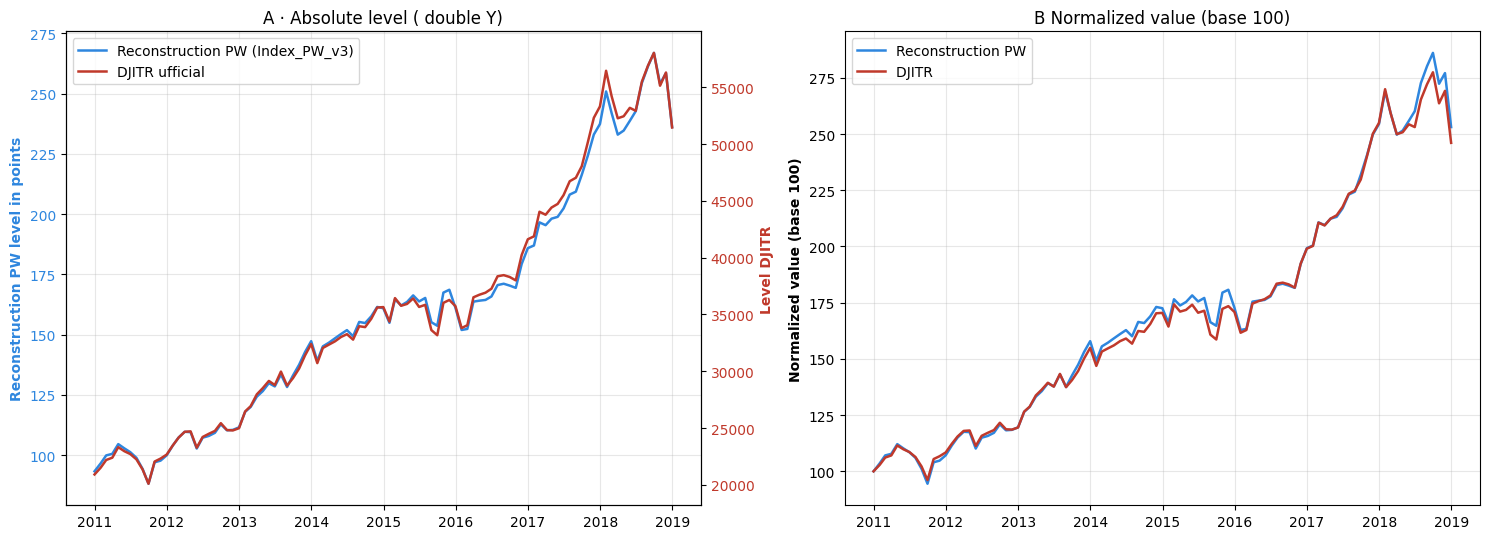

Ret cumulativo ricostruzione : +153.08%
Ret cumulativo DJITR         : +146.07%
Scostamento finale relativo  :   +2.85%


In [9]:
# Filtra i livelli per il periodo di training
START_TRAIN_DATE = pd.Timestamp("2010-12-31")
IS_END           = pd.Timestamp("2018-12-31")

djitr_level_train = djitr_level.loc[START_TRAIN_DATE:IS_END]
recon_level_train = recon_level.loc[START_TRAIN_DATE:IS_END]

print(f"Comparazione dei livelli: DJITR ufficiale vs ricostruzione `Index_PW_v3` per il periodo di training ({START_TRAIN_DATE.date()} → {IS_END.date()})")
plot_level_comparison(djitr_level_train, recon_level_train)

### 3.1 Tracking error della nostra ricostruzione vs DJITR (rolling)

La ricostruzione è la nostra "leva di validazione": se il TE rolling resta
basso in ogni regime, il panel dati dei 30 componenti riproduce fedelmente
il DJITR e qualsiasi alpha delle strategie sarà alpha reale — non rumore
residuo della ricostruzione.

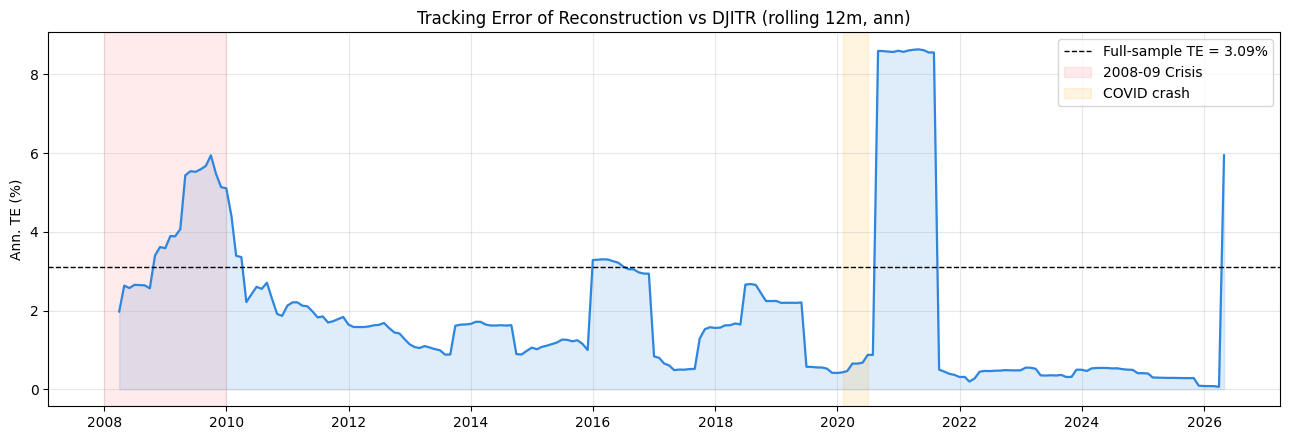

In [10]:
def plot_tracking_error_rolling(recon_return: pd.Series,
                                djitr_return: pd.Series,
                                window: int = 12):
    common = recon_return.index.intersection(djitr_return.index)
    rp, rd = recon_return.loc[common], djitr_return.loc[common]
    te_full = (rp - rd).std() * np.sqrt(12)
    te_roll = (rp - rd).rolling(window).std() * np.sqrt(12)

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(te_roll.index, te_roll * 100, color="#2e86de", lw=1.6)
    ax.fill_between(te_roll.index, 0, te_roll * 100, alpha=0.15, color="#2e86de")
    ax.axhline(te_full * 100, color="k", ls="--", lw=1,
               label=f"Full-sample TE = {te_full*100:.2f}%")
    ax.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-31"),
               color="red", alpha=0.08, label="2008-09 Crisis")
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-06-30"),
               color="orange", alpha=0.12, label="COVID crash")
    ax.set_title(f"Tracking Error of Reconstruction vs DJITR (rolling {window}m, ann)")
    ax.set_ylabel("Ann. TE (%)"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


plot_tracking_error_rolling(recon_return, djitr_return)

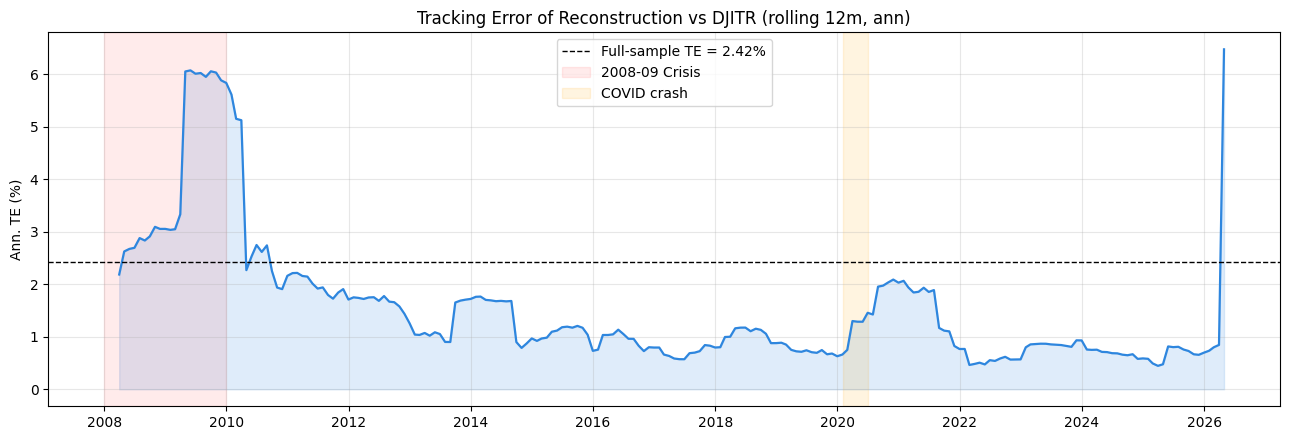

In [11]:
# Plot del Tracking Error rolling per Return_PW
plot_tracking_error_rolling(recon_return_pw, djitr_return)

#  We are gonna use this last reconstruction!!

# Especially because in the IS period TE is very low and unbiased !!
# As we saw before

In [12]:
start_date_ts = pd.to_datetime('2019-01-01')
end_date_ts = pd.to_datetime('2026-03-31')

djitr_filtered = djitr_level.loc[start_date_ts:end_date_ts]

if not djitr_filtered.empty:
    start_level = djitr_filtered.iloc[0]
    end_level = djitr_filtered.iloc[-1]

    compound_return = (end_level / start_level) - 1

    # Calculate number of years for annualization
    num_days = (end_date_ts - start_date_ts).days
    num_years = num_days / 365.25 # Account for leap years

    compound_annual_return = (1 + compound_return)**(1/num_years) - 1

    print(f"Rendimento composto DJITR dal {start_date_ts.date()} al {end_date_ts.date()}: {compound_return:.2%}")
    print(f"Rendimento composto ANNUO DJITR dal {start_date_ts.date()} al {end_date_ts.date()}: {compound_annual_return:.2%}")
else:
    print(f"Nessun dato DJITR disponibile per il periodo {start_date_ts.date()} - {end_date_ts.date()}.")

Rendimento composto DJITR dal 2019-01-01 al 2026-03-31: 114.61%
Rendimento composto ANNUO DJITR dal 2019-01-01 al 2026-03-31: 11.12%


In [13]:
start_date_full = djitr_level.index.min()
end_date_full = djitr_level.index.max()

djitr_full_range = djitr_level.loc[start_date_full:end_date_full]

if not djitr_full_range.empty:
    start_level_full = djitr_full_range.iloc[0]
    end_level_full = djitr_full_range.iloc[-1]

    compound_return_full = (end_level_full / start_level_full) - 1

    # Calculate number of years for annualization
    num_days_full = (end_date_full - start_date_full).days
    num_years_full = num_days_full / 365.25 # Account for leap years

    compound_annual_return_full = (1 + compound_return_full)**(1/num_years_full) - 1

    print(f"Rendimento composto DJITR dal {start_date_full.date()} al {end_date_full.date()}: {compound_return_full:.2%}")
    print(f"Rendimento composto ANNUO DJITR dal {start_date_full.date()} al {end_date_full.date()}: {compound_annual_return_full:.2%}")
else:
    print(f"Nessun dato DJITR disponibile per il periodo {start_date_full.date()} - {end_date_full.date()}.")

Rendimento composto DJITR dal 2007-03-31 al 2026-04-30: 529.01%
Rendimento composto ANNUO DJITR dal 2007-03-31 al 2026-04-30: 10.12%
